# Nested Monte Carlo for CVA

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import numpy as np
import pandas as pd
import gc

from simulation.simulation import (
    simulate_outer_market_paths,
    compute_fixing_window_size,
    simulate_nested_cva,
    simulate_nested_cva_swaptions_gpu,
)
from simulation.stats import cva_stats_swaps, cva_stats_swaptions, plot_contributions
from products.irs.gpu import calibrate_swap_rate_at_par
from products.swaption.cpu import price_bermudan_swaption
import warnings
from numba.core.errors import NumbaPerformanceWarning
warnings.filterwarnings("ignore", category=NumbaPerformanceWarning)
import subprocess
from utils import probe_M_cva


/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In this notebook we consider a bank engaged in bilateral trading with a single client. Let $R$ denote the recovery rate of the client upon its default at time $\tau$ assumed to settle instantaneously ($\delta = 0$). The portfolio is of maturity $T$ and uncollateralized, and we assume no contractual cash flows between the bank and the client at $\tau$. We denote by $MtM$ the mark-to-market process of the portfolio (from the bank's perspective). The credit valuation adjustment at time $t$, what the bank expects to lose due to the counterparty's default, is then given by
$$
\mathrm{CVA}_t
=
\mathbb{E}_t
\left[
\mathbf{1}_{\{t<\tau\leq T\}}\,
\beta_t^{-1}\beta_{\tau}\,
(1-R)\,
(MtM_{\tau})^{+}
\right],
$$ where the stochastic discount factor is defined by 
$\beta_t=\exp\!\left(-\int_0^t r_s\,ds\right)$.
We assume that the short rate $r$ follows Vasicek dynamics.
The client's default time is modeled through a Cox process. The default intensity $\gamma$ follows a CIR dynamics and $\tau = \inf\{t > 0 : \int_0^t \gamma_s\,ds \geq \epsilon\}$ where $\epsilon \sim \mathcal{E}(1)$.

We discretize $[0,T] $ over a grid $0=t_0<t_1<\dots<t_n=T$ with terminal condition $\mathrm{CVA}_{t_n}=0$. 
In this discrete scheme, the default event $\{t_l<\tau\leq t_{l+1}\}$ triggers a loss settled at $t_{l+1}$ with exposure at default $(1-R)(MtM_{t_{l+1}})^+$. 
This implies that for $i=n-1,\dots,0$,
$$
\mathrm{CVA}_{t_i}
=
\mathbb{E}_{t_i}
\left[
\sum_{l=i}^{n-1}
\beta_{t_i}^{-1}\,\beta_{t_{l+1}}\,
(1-R)\,
(MtM_{t_{l+1}})^+\,
\mathbf{1}_{\{t_l<\tau\leq t_{l+1}\}}
\right].

We also introduce (introduced in the course and following Albanese, Crépey, Hoskinson and Saadeddine [[1]](#achs)), the intensity-based formulation of the CVA:
$$
\mathrm{CVA}_t
=
\mathbb{1}_{\{t<\tau\}}\,\mathbb{E}_t\!\left[
\int_t^T
\beta_t^{-1}\,\beta_s\,(1-R)\,(MtM_s)^+\,
\gamma_s\,\exp\!\left(-\int_t^s \gamma_u\,du\right)
ds
\right].
$$
Discretizing the time horizon $[t_i, T]$ on the pricing grid $t_i < t_{i+1} < \dots < t_n = T$ with step $\Delta t_l = t_{l+1} - t_l$, we split the integral over the grid intervals:
$$
\int_{t_i}^{T}
\beta_s\,(MtM_s)^+\,\gamma_s\,\exp\!\left(-\int_{t_i}^s \gamma_u\,du\right)ds
=
\sum_{l=i}^{n-1}
\int_{t_l}^{t_{l+1}}
\beta_s\,(MtM_s)^+\,\gamma_s\,\exp\!\left(-\int_{t_i}^s \gamma_u\,du\right)ds.
$$
An explicit Euler scheme (left) gives for $i = n-1, \dots, 0$:
$$
\mathrm{CVA}_{t_i}
=
\mathbb{E}_{t_i}\!\left[
\sum_{l=i}^{n-1}
\beta_{t_i}^{-1}\,\beta_{t_l}\,(1-R)\,(MtM_{t_l})^+\,
\gamma_{t_l}\,
\exp\!\left(-\sum_{k=i}^{l-1}\gamma_{t_k}\,\Delta t_k\right)\Delta t_l\,
\mathbb{1}_{\{t_i<\tau\}}
\right].
$$
if we set the time step to one year ($\Delta t_l = 1$) :
$$
\mathrm{CVA}_{t_i}
=
\mathbb{E}_{t_i}\!\left[
\sum_{l=i}^{n-1}
\beta_{t_i}^{-1}\,\beta_{t_l}\,(1-R)\,(MtM_{t_l})^+\,
\gamma_{t_l}\,
\exp\!\left(-\sum_{k=i}^{l-1}\gamma_{t_k}\right)
\mathbb{1}_{\{t_i<\tau\}}
\right].
$$

These formulas are the ones implemented in the simulation code.
For numerical implementation, in the explicit Euler formula above $\gamma_{t_l}\,\exp\!\left(-\sum_{k=i}^{l-1}\gamma_{t_k}\,\Delta t_k\right)\Delta t_l$ can be computed as $e^{-\Gamma_{i,l}} - e^{-\Gamma_{i,l+1}}$ where $\Gamma_{i,l} = \int_{t_i}^{t_l}\gamma_u\,du$. Actually using $\gamma_{t_l}\Delta t_l \approx 1 - e^{-\gamma_{t_l}\Delta t_l}$ for small $\gamma_{t_l}\Delta t_l$, we have $\gamma_{t_l}\,\exp\!\left(-\sum_{k=i}^{l-1}\gamma_{t_k}\,\Delta t_k\right)\Delta t_l \approx \left(1 - e^{-\gamma_{t_l}\Delta t_l}\right)\exp\!\left(-\sum_{k=i}^{l-1}\gamma_{t_k}\,\Delta t_k\right) = \exp\!\left(-\sum_{k=i}^{l-1}\gamma_{t_k}\,\Delta t_k\right) - \exp\!\left(-\sum_{k=i}^{l}\gamma_{t_k}\,\Delta t_k\right) = e^{-\Gamma_{i,l}} - e^{-\Gamma_{i,l+1}}$. We do this because $\Gamma_{i,l}$ is already computed during the diffusion of $\gamma$ on the fine SDE simulation/diffusion grid $dt$ and exponentials $e^{-\Gamma_{i,l}}$ are already valued so $\Delta t_l$ and $\Delta t_k$ no longer appear in the expression. The same numerical treatment applies to the discount factor $\beta_{t_i}^{-1}\beta_{t_l}$

The CVA is an anticipation of future default losses conditional on the information $\mathcal{F}_{t_i}$ available at $t_i$. We denote by $Z$ the set of market risk factors (e.g. a Vasicek short rate, a CIR default intensity, an asset price $S_t$) which is Markov by itself and by $X_{t_i} = \mathbf{1}_{\{\tau \leq t_i\}}$ the client's default indicator. The pair $(Z, X)$ is jointly Markov. Conditioning on $\mathcal{F}_{t_i}$ therefore reduces to conditioning on $(Z_{t_i}, X_{t_i})$. [[2]](#achs)

In the following $R = 0$.

In this notebook, we first estimate these conditional expectations by Nested Monte Carlo methods.
An outer i.i.d. sample $\{(Z_{t_i}^{(k)}, \tau^{(k)})\}_{1 \leq k \leq N}$ is drawn. For each outer path $k$, $M$ inner paths drawn conditionally on $(Z_{t_i}, \mathbf{1}_{\{\tau > t_i\}}) = (Z_{t_i}^{(k)}, \mathbf{1}_{\{\tau^{(k)} > t_i\}})$.

For a given outer $k$ two formulations can be used:

Indicator-based formluation ($\tau^{(k,m)}$ re-simulated per inner path):
$$
\widehat{\mathrm{CVA}}_{t_i}^{(k)}
= \frac{1}{M} \sum_{m=1}^{M} \sum_{l=i}^{n-1}
\beta_{t_i}^{-1} \beta_{t_{l+1}}^{(k,m)} \big(MtM_{t_{l+1}}^{(k,m)}\big)^{+}
\mathbf{1}_{\{t_l < \tau^{(k,m)} \leq t_{l+1}\}}.
$$

Intensity-based estimator:
$$
\widehat{\mathrm{CVA}}_{t_i}^{(k)}
= \frac{1}{M} \sum_{m=1}^{M} \sum_{l=i}^{n-1}
\beta_{t_i}^{-1} \beta_{t_l}^{(k,m)} \big(MtM_{t_l}^{(k,m)}\big)^{+}
\Big(e^{-\int_{t_i}^{t_l} \gamma_u^{(k,m)} du} - e^{-\int_{t_i}^{t_{l+1}} \gamma_u^{(k,m)} du}\Big)
\mathbf{1}_{\{t_i < \tau^{(k)}\}}.
$$

As mentioned in [[2]](#acs) and in the course, the intensity-based formulation gives a lower-variance estimator of the CVA. We verify this empirically in what follows.

### Case study 1 : IRS 

In [2]:
## time discretization grid
dT = 0.1 # pricing grid 
num_substeps = 25  # per pricing step
dt = dT / num_substeps # diffusion grid  
T_horizon = 10.0
num_steps_total = round(T_horizon / dT)   

print(f"pricing grid step:        dT = {dT}")
print(f"sub-steps per pricing:    {num_substeps}")
print(f"diffusion grid step:      dt = {dt}")
print(f"horizon:                  T  = {T_horizon}")
print(f"number of pricing steps:  n  = {num_steps_total}")
print(f"number diffusion steps:    {num_steps_total * num_substeps}")

pricing grid step:        dT = 0.1
sub-steps per pricing:    25
diffusion grid step:      dt = 0.004
horizon:                  T  = 10.0
number of pricing steps:  n  = 100
number diffusion steps:    2500


$$
dr_t = a(b - r_t)\,dt + \sigma\, dB^r_t
$$

$$
d\gamma_t = k(\theta - \gamma_t)\,dt + \xi \sqrt{\gamma_t}\, dB^\gamma_t
$$

where $B^r$ and $B^\gamma$ are standard Brownian motions with $d\langle B^r, B^\gamma \rangle_t = \rho\, dt$ ($\rho$ could be seen as a proxy for wrong-way risk but properly modeling WWR is not that straightforward...)

In [3]:
# risk factors parameters 
# Vasicek short rate (a, b, sigma)
# CIR default intensity (k, theta, xi)
a, b, sigma = 0.3, 0.03, 0.01
k, theta, xi = 0.5, 0.015, 0.01
rho = 0  
diff_params = (a, b, sigma, k, theta, xi)
r_0, gamma_0 = 0.01, 0.015

In [4]:
# swaps ptf
np.random.seed(0)

num_irs = 500
reset_freq = 0.5

# bank ptf direction bias
prop_pay_fixed = 0.75  # heavy asset
notional = 10000. * (np.random.choice((-1, 1), num_irs, p=(1 - prop_pay_fixed, prop_pay_fixed)) * np.random.choice(range(1, 11), num_irs))

at_par = False   # if true the mtm=0 at t_0 else fixed swap_rate 

irs = []
for i in range(num_irs):
    trade = {
        'first_reset': reset_freq,
        'reset_freq':  reset_freq,
        'num_resets':  int(np.random.randint(6, 21)),
        'notional':    float(notional[i]),
        'swap_rate':   float(np.random.uniform(0.005, 0.05))  # (course case study), random ITM/OTM
    }
    if at_par:
        trade['swap_rate'] = float(
            calibrate_swap_rate_at_par(trade, r_0, a, b, sigma))
    irs.append(trade)

max_maturity = max(s['num_resets'] for s in irs) * reset_freq

print(f"portfolio: {num_irs} interest rate swaps")
print(f"  - {prop_pay_fixed:.0%} pay fixed, {1-prop_pay_fixed:.0%} receive fixed")
print(f"  - priced at par: {at_par}")
print(f"  - max maturity: {max_maturity:.1f}y")

portfolio: 500 interest rate swaps
  - 75% pay fixed, 25% receive fixed
  - priced at par: False
  - max maturity: 10.0y


In [5]:
# pricing the floating leg of a swap requires the short rate fixed at the previous reset date
# the fixing window size below gives the number of simulation sub-steps between two consecutive resets
# this allows to retrieve the last fixing at any simulation step

fixing_window_size = compute_fixing_window_size(irs, dt, dT)
print("fixing_window_size =", fixing_window_size)

fixing_window_size = 5


As proved in the course and [[3]](#acd), the MSE of the CVA NMC estimator decomposes as $\text{MSE}_{cva} = O\!\left(\frac{1}{M_{cva}} + \frac{1}{M_{mtm}^2}\right)$ where the inner variance is transformed into a bias of the same order. Balancing both contributions leads to $M_{mtm} \sim \sqrt{M_{cva}}$.

In the following apply the two-step procedure based on [[3]](#acd) for both the indicator-based and the intensity-based formulations. 

**Step 1** : Calibrate $M_{cva}$ (with $M_{mtm} = \sqrt{M_{cva}}$)

We double or halve $M_{cva}$ until the relative error at the 95% confidence level reaches 5%:
$$\text{rel.err} = \frac{1.96 \times \hat{\sigma}/\sqrt{M_{cva}}}{|\widehat{\text{CVA}}|} \leq 5\%$$
Here $1.96 \times \hat{\sigma}/\sqrt{M_{cva}}$ is the size of the 95% confidence interval around our estimate. 
This yields $M_{cva}^*$ which would be helpful to run stats or generate reference labels to validate the upcoming learned CVA estimators.

**Step 2** :  Calibrate $M_{mtm}$ (with $M_{cva}^*$ fixed).

We apply a dichotomy on $M_{mtm}$ and rerun the full simulation each time (using the same random seed so that the outer trajectories stay identical across runs to isolate the $M_{mtm}$ effect on the estimate). We keep the smallest/optimal $M_{mtm}$ such that the estimate stops moving by more than the confidence interval size:
$$|\widehat{\text{CVA}}^{(p+1)} - \widehat{\text{CVA}}^{(p)}| < 1.96 \times \hat{\sigma}/\sqrt{M_{cva}^*}$$

We run this procedure independently for both the indicator-based and the intensity-based estimators.

In [9]:
# Step 1: Calibrate M_cva (with M_mtm = sqrt(M_cva))

t_i = 0
t_i_idx = 0
target_rel_err = 0.05  # 5% could be greater

for indicator, label in [(False, "intensity"), (True, "indicator")]:
    print(f"\n Run step 1 - calibrating M_outer - ({label} formulation)")
    
    M_cva = 2**15  
    logs = []
    seed = np.random.randint(0, 2**31 - 1)
    rng = np.random.default_rng(seed)

    while True:
        M_mtm = int(np.sqrt(M_cva))

        X, default_step, _, _ = simulate_outer_market_paths(
        num_outer_paths= M_cva,
        num_steps_total=num_steps_total,
        num_substeps=num_substeps,
        dt=dt,
        fixing_window_size=fixing_window_size,
        r_0=r_0, gamma_0=gamma_0,
        diff_params=diff_params,
        rho=rho, rng=rng)
        cva, ic, rel_err, sec = cva_stats_swaps(
            t_i_idx, M_mtm, indicator,
            X, default_step, irs,
            diff_params, rho, dt, num_substeps, num_steps_total,
            M_cva, fixing_window_size, dT, seed=seed,
        )
        
        rel_frac = rel_err / 100  
        logs.append((M_cva, M_mtm, cva, ic, rel_err, sec))
        print(f"M_cva={M_cva:>6} | M_mtm={M_mtm:>3} | CVA={cva:.2f} | "
              f"CI=±{ic:.2f} | rel.err={rel_err:.2f}% | time={sec:.2f}s")
        
        if rel_frac > target_rel_err:
            print(f"M_cva* = {M_cva * 2}")
            break
        else:
            if M_cva <= 1024:
                print(f"M_cva* = {M_cva} (floor)")
                break
            M_cva //= 2
    
    df = pd.DataFrame(logs, columns=["M_cva", "M_mtm", "CVA value", 
                                         "CI 95%", "rel err. (%)", "exec time (s)"])
    print(df.to_string(index=False))


 Run step 1 - calibrating M_outer - (intensity formulation)
M_cva= 32768 | M_mtm=181 | CVA=5481.36 | CI=±5.17 | rel.err=0.09% | time=269.11s
M_cva= 16384 | M_mtm=128 | CVA=5484.27 | CI=±8.63 | rel.err=0.16% | time=102.64s
M_cva=  8192 | M_mtm= 90 | CVA=5493.07 | CI=±14.68 | rel.err=0.27% | time=37.25s
M_cva=  4096 | M_mtm= 64 | CVA=5483.61 | CI=±24.53 | rel.err=0.45% | time=16.16s
M_cva=  2048 | M_mtm= 45 | CVA=5474.26 | CI=±41.51 | rel.err=0.76% | time=8.40s
M_cva=  1024 | M_mtm= 32 | CVA=5448.22 | CI=±68.12 | rel.err=1.25% | time=4.83s
M_cva* = 1024 (floor)
 M_cva  M_mtm   CVA value    CI 95%  rel err. (%)  exec time (s)
 32768    181 5481.362305  5.168331      0.094289     269.109555
 16384    128 5484.266602  8.626245      0.157291     102.640646
  8192     90 5493.069336 14.682203      0.267286      37.247296
  4096     64 5483.605957 24.531570      0.447362      16.159581
  2048     45 5474.256348 41.511546      0.758305       8.403282
  1024     32 5448.219238 68.119804      1.

All runs are performed on GPU. At equal accuracy target (5% relative error), the indicator formulation requires twice as many outer paths as intensity (2048 vs 1024). At fixed $M_{cva}$ the indicator CI is ~5-6× wider for example ±374 vs ±69 at $M_{cva} = 1024$.

In [ ]:
# Step 2 - Calibrate M_mtm (with M_cva = M_cva_star fixed)

t_i = 0
t_i_idx = 0
M_cva_star = {"intensity": 1024, "indicator": 2048}  
M_mtm_grid = [32, 64, 128]

for indicator, label in [(False, "intensity"), (True, "indicator")]:
    print(f"\n Run step 2 - calibrating M_inner - ({label} formulation)")
    M_cva = M_cva_star[label]
    logs = []
    
    # fixed seed across M_mtm values to isolate MtM effects 
    seed = np.random.randint(0, 2**31 - 1)
    
    prev_cva = None
    M_mtm_star = None
    
    for M_mtm in M_mtm_grid:
        rng = np.random.default_rng(seed) 
        X, default_step, _, _ = simulate_outer_market_paths(
            num_outer_paths=M_cva,
            num_steps_total=num_steps_total,
            num_substeps=num_substeps,
            dt=dt,
            fixing_window_size=fixing_window_size,
            r_0=r_0, gamma_0=gamma_0,
            diff_params=diff_params,
            rho=rho, rng=rng,
        )
        
        cva, ic, rel_err, sec = cva_stats_swaps(
            t_i_idx, M_mtm, indicator,
            X, default_step, irs,
            diff_params, rho, dt, num_substeps, num_steps_total,
            M_cva, fixing_window_size, dT, seed=seed,
        )
        
        logs.append((M_mtm, cva, ic, rel_err, sec))
        print(f"M_mtm={M_mtm:>4} | CVA={cva:.2f} | CI=±{ic:.2f} | "
              f"rel.err={rel_err:.2f}% | time={sec:.2f}s")
        
        # Marking the Mtm*
        if prev_cva is not None and M_mtm_star is None and abs(cva - prev_cva) < ic:
            M_mtm_star = M_mtm
        prev_cva = cva

    if M_mtm_star is not None:
        print(f"M_mtm* = {M_mtm_star}")
    else:
        print(f"No stabilization in grid, M_mtm* = {M_mtm_grid[-1]} (max)")

    df = pd.DataFrame(logs, columns=["M_mtm", "CVA value", "CI 95%", 
                                  "rel err. (%)", "exec time (s)"])
    print(df.to_string(index=False))


 Run step 2 - calibrating M_inner - (intensity formulation)
M_mtm=  32 | CVA=5440.94 | CI=±69.77 | rel.err=1.28% | time=4.83s
M_mtm=  64 | CVA=5437.08 | CI=±47.92 | rel.err=0.88% | time=9.65s
M_mtm= 128 | CVA=5444.28 | CI=±33.75 | rel.err=0.62% | time=19.30s
M_mtm* = 64
 M_mtm   CVA value    CI 95%  rel err. (%)  exec time (s)
    32 5440.942383 69.770958      1.282332       4.826944
    64 5437.078125 47.918575      0.881330       9.647880
   128 5444.282227 33.749500      0.619907      19.300282

 Run step 2 - calibrating M_inner - (indicator formulation)
M_mtm=  32 | CVA=5345.50 | CI=±258.52 | rel.err=4.84% | time=6.12s
M_mtm=  64 | CVA=5456.47 | CI=±189.97 | rel.err=3.48% | time=12.24s
M_mtm= 128 | CVA=5448.79 | CI=±133.55 | rel.err=2.45% | time=24.48s
M_mtm* = 64
 M_mtm   CVA value     CI 95%  rel err. (%)  exec time (s)
    32 5345.501953 258.523142      4.836274       6.122591
    64 5456.466797 189.966541      3.481494      12.242306
   128 5448.791992 133.548988      2.450983

For the intensity-based formulation with $M_{cva} = 1024$ fixed, taking $M_{mtm} = 64$ is already enough as the gain in bias that results from taking higher $M_{mtm}$ is negligible wrt the size of the confidence interval. For $M_{mtm} = 64$ and $128$ only differ by 7 which is below the outer CI half-width of $\pm 48$. For the indicator formulation with $M_{cva} = 2048$ fixed, also taking $M_{mtm} = 64$ is already enough as for $M_{mtm} = 64$ and $128$ only differ by 8 well below the outer CI half-width of $\pm 190$.
We also note here that the outer MC variance is significantly larger for the indicator formulation than for the intensity formulation. This is also confirmed below where the per-path contributions are well concentrated around the mean for the intensity formulation while the indicator based formulation exhibits a much wider spread with a heavy tail on the right. The running CVA estimate $\widehat{\text{CVA}}^{(n)} = \frac{1}{n} \sum_{j=1}^{n} \xi_j$, where $\xi_j$ is the contribution of the $j$-th outer trajectory to the CVA estimator, converges much faster for intensity than for indicator.

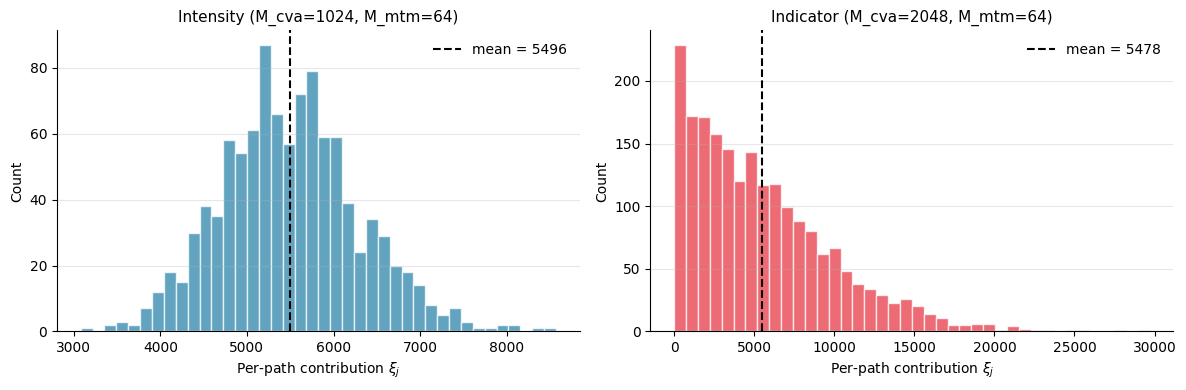

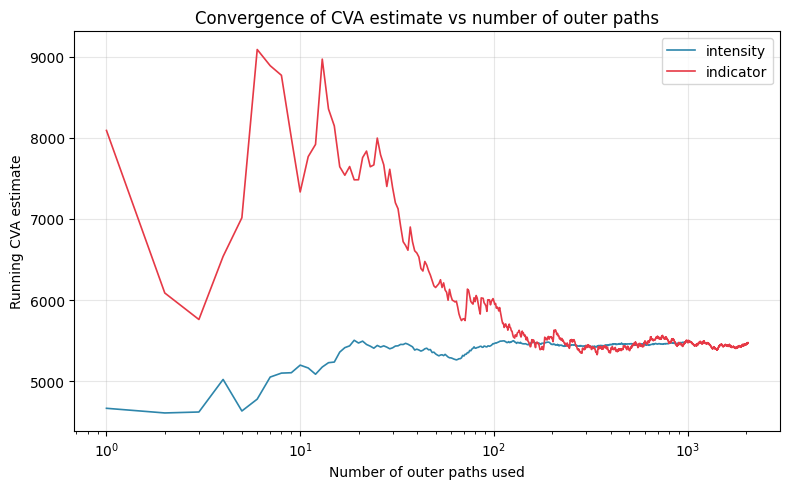

In [ ]:
M_cva_star = {"intensity": 1024, "indicator": 2048}
M_mtm_star = {"intensity": 64, "indicator": 64}
seed = np.random.randint(0, 2**31 - 1)

kwargs = dict(
    M_cva_star=M_cva_star, M_mtm_star=M_mtm_star, seed=seed,
    num_steps_total=num_steps_total, num_substeps=num_substeps, dt=dt,
    fixing_window_size=fixing_window_size,
    r_0=r_0, gamma_0=gamma_0,
    diff_params=diff_params, rho=rho, irs=irs, dT=dT,
)

plot_contributions(**kwargs, plot_type="hist")
plot_contributions(**kwargs, plot_type="running_mean")

### Case study 2 : Bermudan swaption

In the previous case of a book of swaps, $\text{MtM}$ was analytic. We now add a Bermudan swaption where the holder may enter the underlying swap at any date of a discrete exercise grid $\Re = \{s_0, \dots, s_{N_b}\} \subset \{t_0, \dots, t_n\}$ with maturity $T$. As noted in [[3]](#acd) and in the course, a non-analytic $MtM$ would in principle require an extra layer of inner simulations.

Let $\varphi$ denote the exercise payoff. The pre-default pricing function satisfies at each exercise date $s_k$ is given by 

$$P(s_k, Z_{s_k}) = \operatorname*{ess\,sup}_{\theta \in \mathcal{T}^k} \mathbb{E}\!\left[\tfrac{\beta_\theta}{\beta_{s_k}} \varphi(Z_\theta) \,\big|\, Z_{s_k}\right],$$

where $\mathcal{T}^k$ is the set of stopping times valued in $\{s_k, \dots, s_{N_b}\}$. The optimal stopping time is obtained by the standard backward recursion $\tau^*_{N_b} = T$ and, for $k$ decreasing from $N_b - 1$ to $0$,

$$\tau^*_k = s_k \mathbf{1}_{A_k} + \tau^*_{k+1} \mathbf{1}_{A_k^c}, \qquad A_k = \big\{ \beta_{s_k} \varphi(Z_{s_k}) > \mathbb{E}[\beta_{s_{k+1}} P(s_{k+1}, Z_{s_{k+1}}) \mid Z_{s_k}] \big\},$$

so that $\text{MtM}_{s_k} = P(s_k, Z_{s_k}) = \mathbb{E}[\beta_{s_k}^{-1} \beta_{\tau^*_k} \varphi(Z_{\tau^*_k}) \mid Z_{s_k}]$. The conditional expectations defining $A_k$ are approximated by Longstaff-Schwartz regression on a polynomial basis of $Z_{s_k}$ [[3]](#acd) [[4]](#course).

In the nested monte carlo context, this Longstaff-Schwartz procedure is re-run inside each outer simulation at every outer node $(t_i, Z_{t_i}^{(k)})$ where $\text{MtM}$ is needed, $M$ inner trajectories of the risk factor $Z$ are simulated from that point and a local Longstaff-Schwartz gives the inner estimator $\widehat{\text{MtM}}^{(k,m)}$ which is then plugged into the CVA we've seen above.

In this context $\varphi(Z_{s_k}) = \big(V^{\text{swap}}(s_k, Z_{s_k})\big)^+$ where $V^{\text{swap}}(s_k, Z_{s_k})$ is the value at $s_k$ of the underlying swap.

In this section we determine teh CVA at $t = 0$ (no inner conditioning). 
The NMC reduces to two layers :
- Outer : $M_{cva}$ paths of $(r, \gamma, \tau)$ simulated once from $0$ to $T$
- Inner LS : $M_{LS}$ paths used locally for the Longstaff-Schwartz pricing at every outer node where the MtM is needed

Plugging this into the indicator-based estimator for example for outer path $k$:

$$
\widehat{\mathrm{CVA}}_0^{(k)} = \sum_{l=0}^{n-1} \beta_{t_{l+1}}^{(k)} \Big(\widehat{\mathrm{MtM}}_{t_{l+1}}^{(k)}\Big)^+ \mathbf{1}_{\{t_l < \tau^{(k)} \leq t_{l+1}\}}
$$

The GPU kernel for thsi nmc simualtion is built around the natural mapping 1 thread = 1 outer path. Each thread runs sequentially the full inner LS for each swaption of the book. This is also presented in [[3]](#acd) (Appendix). Other implementation choices were interesting to add. The polynomial regression of the continuation value is restricted to in-the-money paths only to improve accuracy [[5]](#giles). Moreover, the regression step at each LS iteration requires solving many small symmetric positive-definite systems in parallel (one per outer node per exercise date per swaption) as standard regression operators (such as numpy's lstsq) are not available on GPU. The regression step is therefore implemented via a Cholesky factorization following a dedicated GPU strategy [[3]](#acd) [[6]](#atg).

In [ ]:
# please make sure to have run the params/IRS book setup cell above before running this cell
# swaptions book
np.random.seed(1)

num_swaptions = 100
reset_freq = 0.5

# bank ptf direction bias/ heavy asset
prop_payer = 0.75
swap_types = np.random.choice((-1, 1), num_swaptions, p=(1 - prop_payer, prop_payer))
notional = 10000. * np.random.choice(range(1, 11), num_swaptions)

swaptions = []
for i in range(num_swaptions):
    trade = {
        'first_reset': float(np.random.choice([1.0, 1.5, 2.0])),  # non-callable period/lock-out drawn in {1y, 1.5y, 2y}
        'reset_freq':  reset_freq,
        'num_resets':  int(np.random.randint(10, 17)),
        'notional':    float(notional[i]),
        'swap_rate':   float(np.random.uniform(0.005, 0.05)),
        'swap_type':   int(swap_types[i]),
    }
    swaptions.append(trade)

max_maturity = max(s['first_reset'] + (s['num_resets'] - 1) * reset_freq for s in swaptions)
print(f"{num_swaptions} swaptions | p_payer={prop_payer} | "
      f"lock-out in [1.0, 2.0]y | max maturity={max_maturity:.1f}y")

100 swaptions | p_payer=0.75 | lock-out in [1.0, 2.0]y | max maturity=9.5y


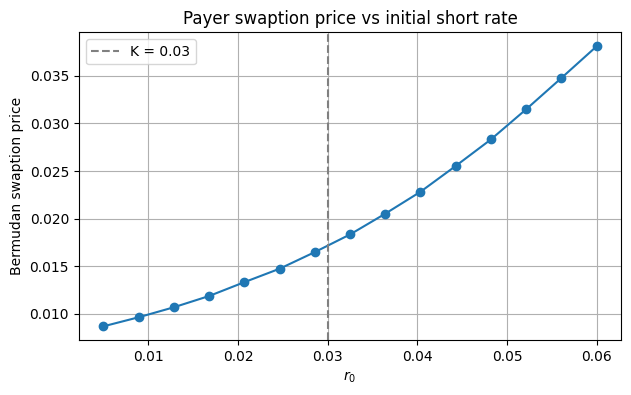

In [ ]:
# sanity check
# payer swaption price as a function of the initial short rate
#swaption_test = {
#    'first_reset': 2.0, 'reset_freq': 0.5, 'num_resets': 11,
#    'swap_rate': 0.03, 'swap_type': 1, 'notional': 1.0,
#}

#r_0_grid = np.linspace(0.005, 0.06, 15)  # ITM/ATM/OTM regimes
#prices = []
#for r0 in r_0_grid:
#    rng = np.random.default_rng(42)
#    p = price_bermudan_swaption(
#       t=0.0, r_0=r0, swaption=swaption_test,
#        M=5000, dt=0.02, a=0.3, b=0.03, sigma=0.01, N_b=3, rng=rng,
#   )
#   prices.append(p)

#plt.figure(figsize=(7, 4))
#plt.plot(r_0_grid, prices, 'o-')
#plt.axvline(swaption_test['swap_rate'], ls='--', c='gray',
#            label=f"K = {swaption_test['swap_rate']}")
#plt.xlabel("$r_0$")
#plt.ylabel("Bermudan swaption price")
#plt.title("Payer swaption price vs initial short rate")
#plt.legend()
#plt.grid(True)
#plt.show()

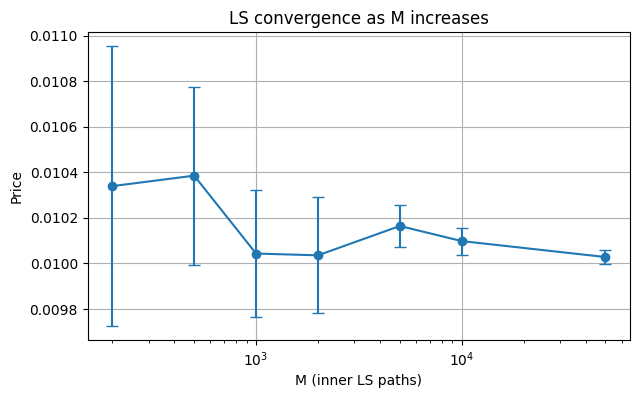

In [ ]:
# testing LS convergence
# for each M run 10 independent estimates + varying the seed
#M_grid = [200, 500, 1000, 2000, 5000, 10000, 50000]
#n_repeats = 10

#mean_prices = []
#ic_95 = []
#for M in M_grid:
#    samples = [price_bermudan_swaption(
#        t=0.0, r_0=0.01, swaption=swaption_test,
#        M=M, dt=0.02, a=0.3, b=0.03, sigma=0.01, N_b=3,
#        rng=np.random.default_rng(seed),
#    ) for seed in range(n_repeats)]
#    mean_prices.append(np.mean(samples))
#    ic_95.append(1.96 * np.std(samples, ddof=1) / np.sqrt(n_repeats))

#plt.figure(figsize=(7, 4))
#plt.errorbar(M_grid, mean_prices, yerr=ic_95, fmt='o-', capsize=4)
#plt.xscale('log')
#plt.xlabel("M (inner LS paths)")
#plt.ylabel("Price")
#plt.title("LS convergence as M increases")
#plt.grid(True)
#plt.show()

price stabilizes around as M grows and the 95% CI shrinks.

All experiments in this notebook are run on a single GPU.

In [ ]:
#gpu_name = subprocess.check_output(
#    ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"]
#).decode().strip()
#print(f"GPU: {gpu_name}")

GPU: NVIDIA A100-PCIE-40GB


We had several memory issues when increasing $M_{cva}$ on the GPU which is consistent with [[3]](#acd) where memory bandwidth is identified as the main bottleneck of GPU programming.
We first identify the largest $M_{\text{cva}}$ compatible with our setup, then fix it and study the stabilization in $M_{\text{LS}}$.

In [ ]:
# Probing the largest M_cva that fits in GPU memory for a fixed M_LS.
# try increasing candidates and return the last one that ran without error.
for indicator, label in [(False, "intensity"), (True, "indicator")]:
    print(f"\n{label} formulation:")
    probe_M_cva([1024, 2048, 4096], 64, indicator, swaptions,
                num_steps_total, num_substeps, dt, dT, fixing_window_size,
                r_0, gamma_0, diff_params, rho)


intensity formulation:
  M_cva= 1024 | OK   | CVA=5052.58 | CI=±184.17 | rel.err=3.65% | time=337.05s
  M_cva= 2048 | OK   | CVA=5041.77 | CI=±126.87 | rel.err=2.52% | time=389.41s
  M_cva= 4096 | OK   | CVA=5040.58 | CI=±89.41 | rel.err=1.77% | time=472.12s

indicator formulation:
  M_cva= 1024 | OK   | CVA=4858.56 | CI=±1153.13 | rel.err=23.73% | time=7.80s
  M_cva= 2048 | OK   | CVA=4702.24 | CI=±815.05 | rel.err=17.33% | time=8.56s
  M_cva= 4096 | OK   | CVA=4726.86 | CI=±597.55 | rel.err=12.64% | time=11.05s


Both formulations converge to the same CVA at $M_{\text{cva}} = 4096$, but the intensity formulation reaches a relative error of ~1.8% against ~12.6% for the indicator one.

In [ ]:
# Upcoming cells study the convergence of the for the swaptions book
# CVA vs M_LS (number of paths in the inner Longstaff-Schwartz regression)

num_outer_paths_test = 1024
num_inner_ls_grid = [16, 32, 64]

rng = np.random.default_rng(42)
X_swpt, default_step_swpt, rate_integral_path_swpt, gamma_integral_path_swpt = simulate_outer_market_paths(
    num_outer_paths=num_outer_paths_test,
    num_steps_total=num_steps_total,
    num_substeps=num_substeps,
    dt=dt,
    fixing_window_size=fixing_window_size,
    r_0=r_0, gamma_0=gamma_0,
    diff_params=diff_params,
    rho=rho, rng=rng,
)
print(f"outer paths simulated | defaults: {(default_step_swpt != -1).sum()}/{num_outer_paths_test}")

for indicator, label in [(False, "intensity"), (True, "indicator")]:
    rows = []
    for n_inner in num_inner_ls_grid:
        cva, ic, rel, sec = cva_stats_swaptions(
            n_inner, indicator, swaptions,
            X_swpt, default_step_swpt,
            rate_integral_path_swpt, gamma_integral_path_swpt,
            diff_params, rho, dt, dT, num_substeps, num_steps_total,
            num_outer_paths_test, fixing_window_size, seed=42,
        )
        rows.append([n_inner, f"{cva:.2f}", f"±{ic:.2f}",
                     f"{rel:.2f}%", f"{sec:.2f}"])
    df = pd.DataFrame(rows, columns=["M_LS (inner LS paths)", "CVA value",
                                     "CI 95%", "rel err.", "exec time (sec)"])
    print(f"\n CVA swaptions ({label}), M_cva={num_outer_paths_test}")
    print(df.to_string(index=False))

outer paths simulated | defaults: 139/1024

 CVA swaptions (intensity), M_cva=1024
 M_LS (inner LS paths) CVA value  CI 95% rel err. exec time (sec)
                    16   5162.32 ±196.88    3.81%           87.69
                    32   5125.03 ±196.40    3.83%          167.66
                    64   5083.43 ±196.24    3.86%          335.52

 CVA swaptions (indicator), M_cva=1024
 M_LS (inner LS paths) CVA value   CI 95% rel err. exec time (sec)
                    16   4995.38 ±1328.86   26.60%            2.01
                    32   4980.99 ±1321.94   26.54%            3.74
                    64   4945.70 ±1317.09   26.63%            8.02


In [10]:
num_outer_paths_test = 2048
num_inner_ls_grid = [16, 32, 64]

rng = np.random.default_rng(42)
X_swpt, default_step_swpt, rate_integral_path_swpt, gamma_integral_path_swpt = simulate_outer_market_paths(
    num_outer_paths=num_outer_paths_test,
    num_steps_total=num_steps_total,
    num_substeps=num_substeps,
    dt=dt,
    fixing_window_size=fixing_window_size,
    r_0=r_0, gamma_0=gamma_0,
    diff_params=diff_params,
    rho=rho, rng=rng,
)
print(f"outer paths simulated | defaults: {(default_step_swpt != -1).sum()}/{num_outer_paths_test}")

for indicator, label in [(False, "intensity"), (True, "indicator")]:
    rows = []
    for n_inner in num_inner_ls_grid:
        cva, ic, rel, sec = cva_stats_swaptions(
            n_inner, indicator, swaptions,
            X_swpt, default_step_swpt,
            rate_integral_path_swpt, gamma_integral_path_swpt,
            diff_params, rho, dt, dT, num_substeps, num_steps_total,
            num_outer_paths_test, fixing_window_size, seed=42,
        )
        rows.append([n_inner, f"{cva:.2f}", f"±{ic:.2f}",
                     f"{rel:.2f}%", f"{sec:.2f}"])
    df = pd.DataFrame(rows, columns=["M_LS (inner LS paths)", "CVA value",
                                     "CI 95%", "rel err.", "exec time (sec)"])
    print(f"\n CVA swaptions ({label}), M_cva={num_outer_paths_test}")
    print(df.to_string(index=False))

outer paths simulated | defaults: 291/2048

 CVA swaptions (intensity), M_cva=2048
 M_LS (inner LS paths) CVA value  CI 95% rel err. exec time (sec)
                    16   5237.46 ±131.99    2.52%           97.19
                    32   5198.56 ±131.71    2.53%          194.58
                    64   5156.63 ±131.60    2.55%          389.48

 CVA swaptions (indicator), M_cva=2048
 M_LS (inner LS paths) CVA value  CI 95% rel err. exec time (sec)
                    16   5812.74 ±950.94   16.36%            2.08
                    32   5741.46 ±942.67   16.42%            4.16
                    64   5710.30 ±939.80   16.46%            8.40


Doubling $M_{\text{cva}}$ from 1024 to 2048 reduces both confidence intervals ( for intensity: 3.8% to 2.5% and for indicator: 26.6% to 16.4%). 
CVA values themselves still are not satble across $M_{\text{LS}}$, suggesting that $M_{\text{LS}} = 64$ is not yet large enough to fully stabilize the inner Longstaff-Schwartz pricing. 
Pushing $M_{\text{LS}}$ higher crashed the GPU memory which reflects the local-memory-per-thread limitation. 
More work on shared-memory usage is needed to relax this constraint and fully exploit the GPU.

## References

<a id="achs"></a>
**[1]** C. Albanese, S. Crépey, R. Hoskinson, B. Saadeddine.
*XVA Analysis From the Balance Sheet.* Quantitative Finance, 21(1), 99–123, 2021.

<a id="acs"></a>
**[2]** L. A. Abbas-Turki, S. Crépey, B. Saadeddine.
*Pathwise CVA Regressions With Oversimulated Defaults.* Mathematical Finance, 2022.

<a id="acd"></a>
**[3]** L. A. Abbas-Turki, S. Crépey, B. Diallo.
*XVA Principles, Nested Monte Carlo Strategies, and GPU Optimizations.* International Journal of Theoretical and Applied Finance, 21(6), 1850030, 2018.

<a id="course"></a>
**[4]** J.F. Chassagneux.  
*Numerical Methods in Financial Engineering.* Course notes, 2026.

<a id="giles"></a>
**[5]** M. Giles.
*Advanced Monte Carlo Methods: American Options.* Lecture notes, Oxford University Mathematical Institute.

<a id="atg"></a>
**[6]** L. A. Abbas-Turki, S. Graillat.
*Resolution of a large number of small random symmetric linear systems in single precision arithmetic on GPUs.* Journal of Supercomputing, 73(4), 1360–1386, 2017.

<a id="ls"></a>
**[7]** F. A. Longstaff, E. S. Schwartz.
*Valuing American Options by Simulation: A Simple Least-Squares Approach.* Anderson Graduate School of Management, Finance, UCLA, 2001.

<a id="aaad"></a>
**[8]** B. Saadeddine. *NeuralXVA: simulation and neural-net learning of path-wise XVAs.* GitHub repository, 2020.

<a id="gpw"></a>
**[9]** M. Germain, H. Pham, X. Warin.
 *Approximation error analysis of some deep backward schemes for nonlinear PDEs.* SIAM Journal on Scientific Computing, 43(5), 2021.

<a id="acss"></a>
**[10]** L. Abbas-Turki, S. Crépey, B. Saadeddine, W. Sabbagh.
 *Pathwise XVAs: The Direct Scheme.* Preprint, 31 October 2022.

<a id="fg"></a>
**[11]** R. Ferguson, A. Green. 
*Deeply Learning Derivatives.* Preprint, version 2.1, 14 October 2018. arXiv:1809.02233.

<a id="markall"></a>
**[12]** G. Markall.
*Numba for CUDA Programmers.* NVIDIA, course materials (5 sessions), 2021.

<a id="he"></a>
**[13]** K. He, X. Zhang, S. Ren, J. Sun.
*Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification.* Proceedings of the IEEE International Conference on Computer Vision (ICCV), 2015. arXiv:1502.01852.